In [2]:
import os

import matplotlib.pyplot as plt

import components.broadcast_components.broadcasting_process.broadcast_reporting_utilities
from components.broadcast_components.broadcasting_process.broadcast_reporting_utilities import plot_stats
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN
import components.broadcast_components.broadcasting_process.WZ_broadcast

import numpy as np
import gzip
import torch
import pickle
import importlib

torch.set_float32_matmul_precision('medium')

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

In [3]:
grad_list_rid_wid = []
for rid in range(len(os.listdir('exp_data/save_grads_per_round'))//2):
    grad_list_rid_wid.append([])
    for wid in range(2):
        path_to_file = f'exp_data/save_grads_per_round/grad_round_{rid}_worker_{wid}.pkl.gz'
        with gzip.open(path_to_file, 'rb') as f:
            grad_list_rid_wid[-1].append({k: a.cpu() for k, a in pickle.load(f).items()})

In [4]:
model_shape_dict = {k:v.numpy().shape for k, v in grad_list_rid_wid[0][0].items()}

In [5]:
importlib.reload(components.broadcast_components.broadcasting_process.WZ_broadcast)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
importlib.reload(components.broadcast_components.broadcasting_process.broadcast_reporting_utilities)
from components.broadcast_components.broadcasting_process.WZ_broadcast import WZBroadcastProtocol
from components.broadcast_components.broadcasting_process.broadcast_reporting_utilities import BroadcastMetricGatheringUtilities

import random
random.seed(10)
np.random.seed(10)

worker_count = 2

wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=2, bins_per_plane=16, tau=2,
                                 reconst_ld=400, lr=1e-3, marginal=True).to(torch.float32)
wz_model.load_state_dict(torch.load('../data/basicRNN_2plane_4bins_state.pt', map_location='cpu'))
base_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=0, enable_progress_bar=True)
broadcast_prot_base = WZBroadcastProtocol(worker_count, base_quantizer)
broadcast_prot = BroadcastMetricGatheringUtilities(broadcast_prot_base)

for round, grad_per_round in enumerate(grad_list_rid_wid):
    if round == 1: break

    for ag_id, grad in enumerate(grad_per_round):
        broadcast_prot.start_round_agent_process(ag_id, round)

        print(f'>> Round {round}, Agent {ag_id}')
        _ = broadcast_prot.model_transfer_to_worker_from_server(grad)

        print('          - Preparing data for transfer to worker...')
        server_data_sent_to_worker = broadcast_prot.to_worker_prep_data_for_transfer(ag_id)

        print('          - Preparing data for transfer to server...')
        encoded_ag_broadcast = broadcast_prot.to_server_prep_data_for_transfer(
                        ag_id, grad, server_data_sent_to_worker)

        print('          - reconstructing data received...')
        decoded_agent_broadcast = broadcast_prot.reconstruction_process(
            ag_id, encoded_ag_broadcast, worker_count, model_shape_dict)

>> Round 0, Agent 0
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
>> Round 0, Agent 1
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

In [6]:
from components.broadcast_components.broadcasting_process.WZ_broadcast import dict_to_array, normalize_array_data
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
from components.broadcast_components.WZ_models.wz_quant_ANN import plot_bins

def f(grad_dict):
    shapes_dict = {k: v.shape for k, v in grad_dict.items()}
    grad_flat = dict_to_array(grad_dict)
    grad_flat_normal, norm_fact_vec = normalize_array_data(grad_flat, shapes_dict, outlier_rem=False, normalize=True)
    return grad_flat_normal


how well the trained data is reconstructed (prev_targ_at_serv)
bins used: 16


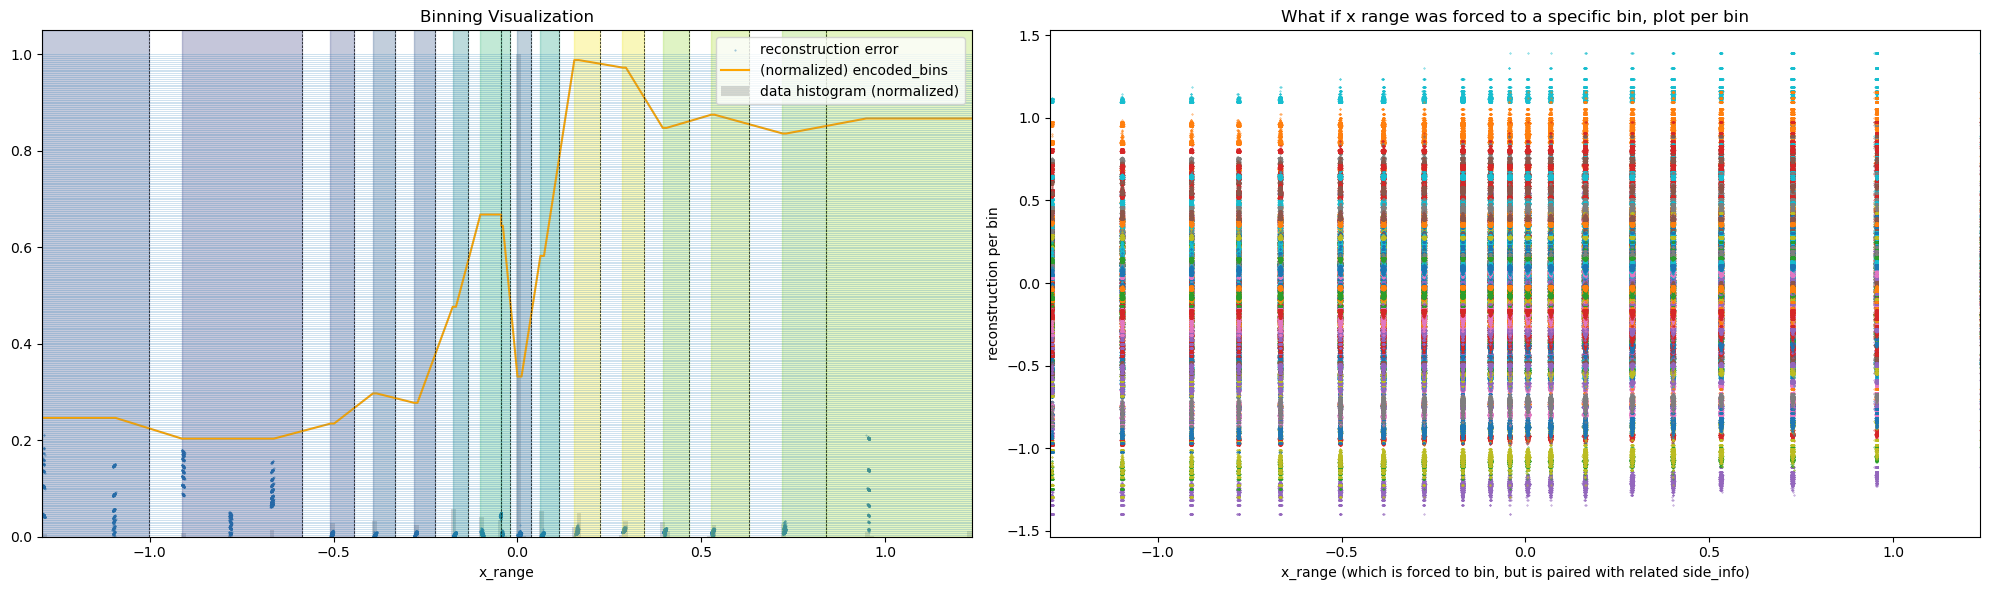

how well the intended next agent grad is recons (y)
bins used: 19


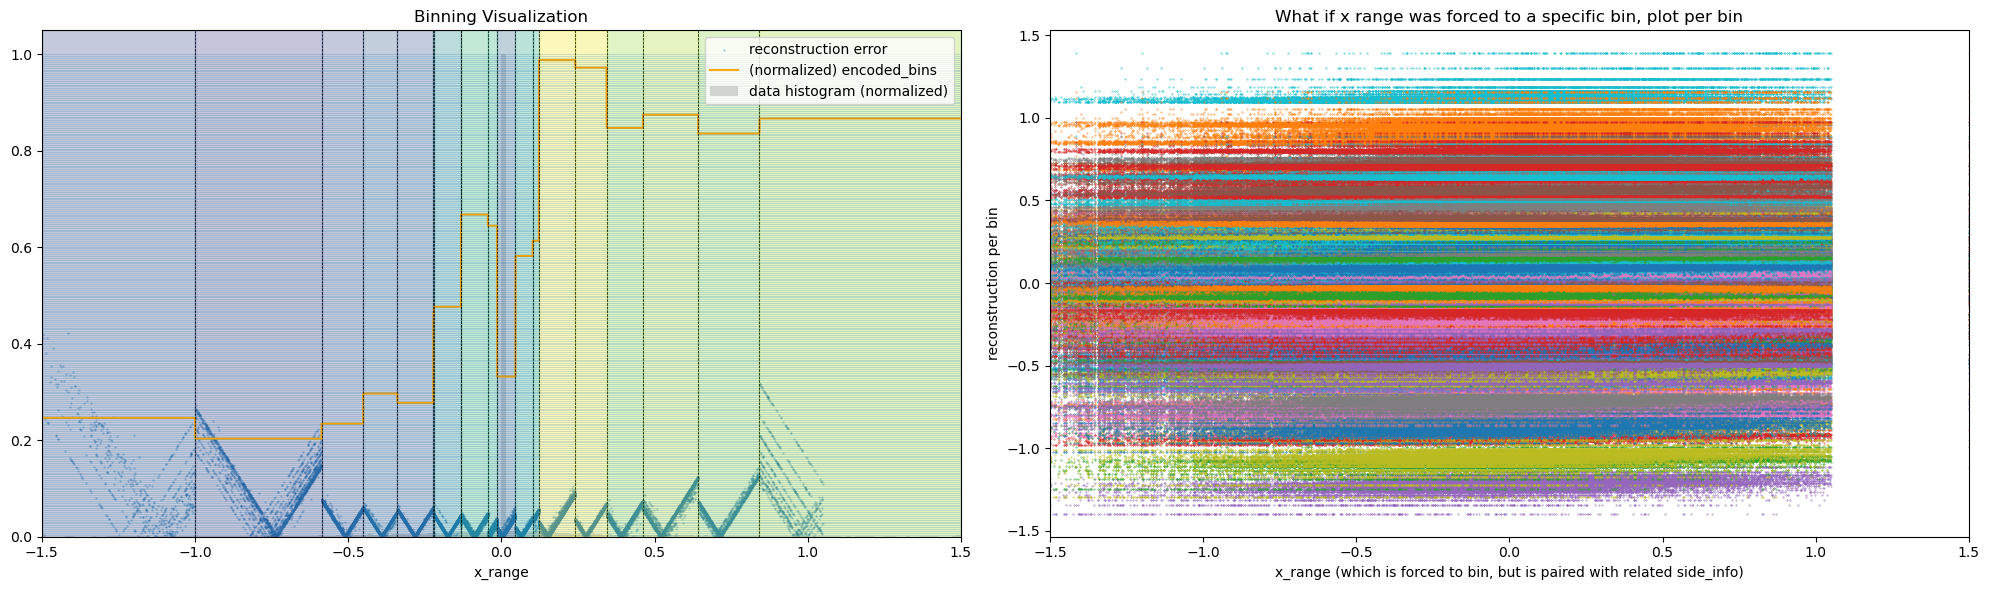

how well the original continues training data is recons (prev_targ_real)
bins used: 19


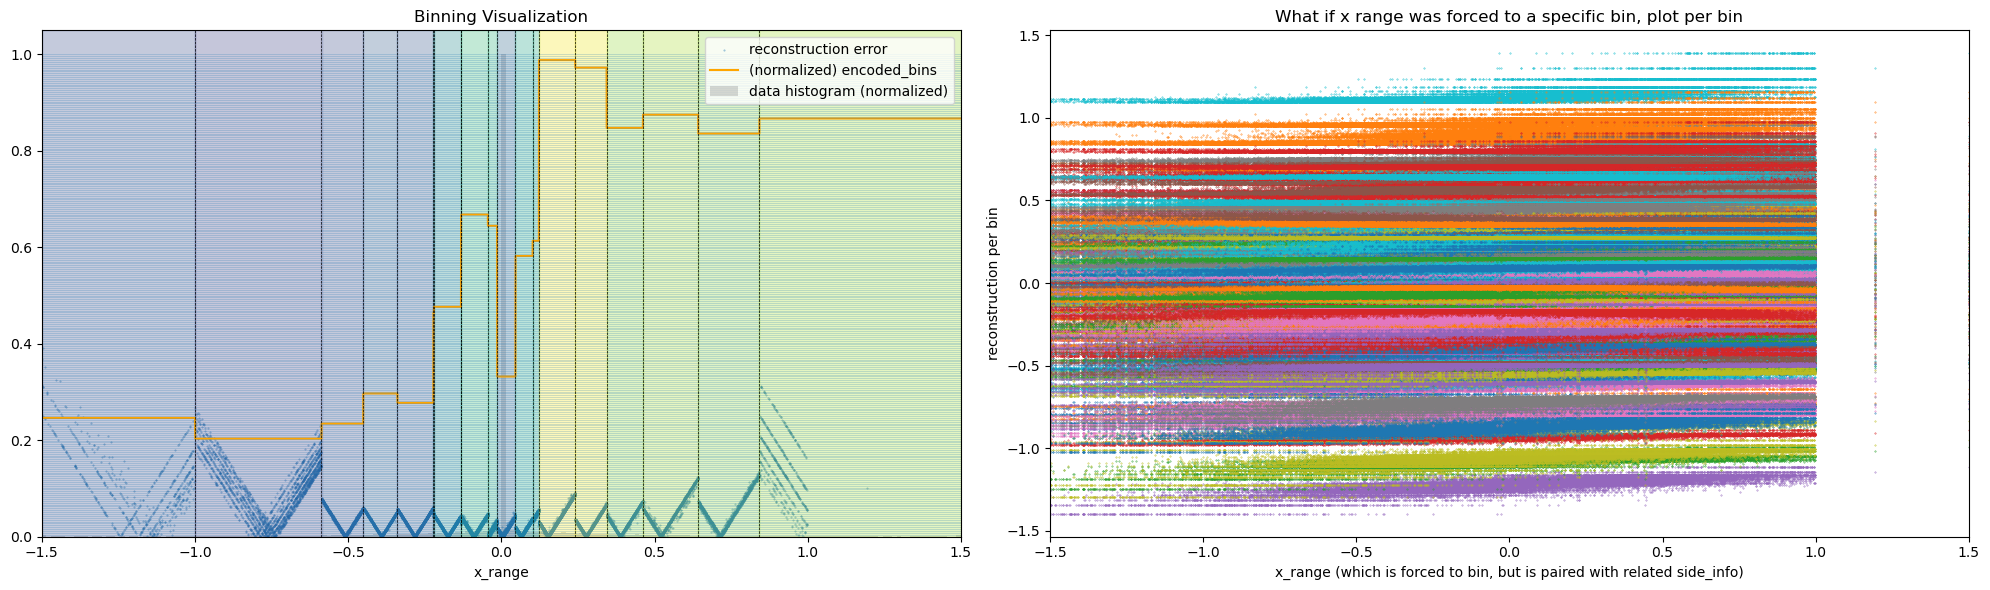

In [7]:
y=f(grad_list_rid_wid[1][0])
prev_targ_real=f(grad_list_rid_wid[0][0])
prev_targ_at_serv=broadcast_prot.prev_d_flat[0]+np.random.normal(0, np.sqrt(1e-6), len(y), ).astype(np.float32)
side_info = broadcast_prot.prev_d_flat[:0] + broadcast_prot.prev_d_flat[0 + 1:]
wz_quantizer:WZQuantizer = broadcast_prot.wz_quantizer_list[0]

temp = np.random.choice(np.arange(len(y)), min(len(y), 100_000), replace=False)
print('how well the trained data is reconstructed (prev_targ_at_serv)')
plot_bins(wz_quantizer, prev_targ_at_serv[temp], [a[temp] for a in side_info], step_count=min(len(temp), 10_000))
print('how well the intended next agent grad is recons (y)')
plot_bins(wz_quantizer, y[temp], [a[temp] for a in side_info], step_count=min(len(temp), 10_000))
print('how well the original continues training data is recons (prev_targ_real)')
plot_bins(wz_quantizer, prev_targ_real[temp], [a[temp] for a in side_info], step_count=min(len(temp), 10_000))

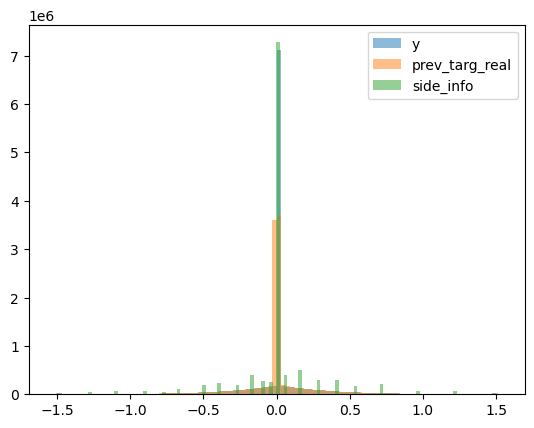

In [8]:
plt.hist(y, bins=100, alpha=0.5, label='y')
plt.hist(prev_targ_real+np.random.normal(0, np.sqrt(1e-4), len(prev_targ_real), ).astype(np.float32), bins=100, alpha=0.5, label='prev_targ_real')
plt.hist(side_info, bins=100, alpha=0.5, label='side_info')
plt.legend()

In [25]:
import lightning

correction_model = torch.nn.Sequential(
    torch.nn.Linear(1, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 1)
)

# Create a simple Lightning module for the correction model
class CorrectionModel(lightning.LightningModule):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.loss_fn = torch.nn.MSELoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss_fn(y_hat, y)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

correction_model_pl = CorrectionModel(correction_model)

temp = np.random.choice(np.arange(len(y)), 1_000, replace=False)
y_pred = wz_quantizer.decoding_process(wz_quantizer.encoding_process(y[temp]), [a[temp] for a in side_info])

# Create data module for training
train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(y_pred, dtype=torch.float32).unsqueeze(1),
    torch.tensor(y[temp], dtype=torch.float8_e4m3fn).unsqueeze(1).to(torch.float32)
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1000, shuffle=True)

# Train the model
trainer = lightning.Trainer(max_epochs=100, enable_progress_bar=True)
trainer.fit(correction_model_pl, train_loader)



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | model   | Sequential | 1.2 K  | train
1 | loss_fn | MSELoss    | 0      | train
-----------------------------------------------
1.2 K     Trainable params
0         Non-trainable params
1.2 K     Total params
0.005     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

In [34]:
temp = np.random.choice(np.arange(len(y)), 10_000, replace=False)
y_pred = torch.tensor(wz_quantizer.decoding_process(wz_quantizer.encoding_process(y[temp]), [a[temp] for a in side_info]), dtype=torch.float32)
y_pred_corrected = correction_model_pl(y_pred.unsqueeze(1)).squeeze().detach().numpy()
sort_idx = np.argsort(y[temp])
temp = [(y_pred_corrected[sort_idx]-y[temp][sort_idx])**2, (y_pred.numpy()[sort_idx]-y[temp][sort_idx])**2]

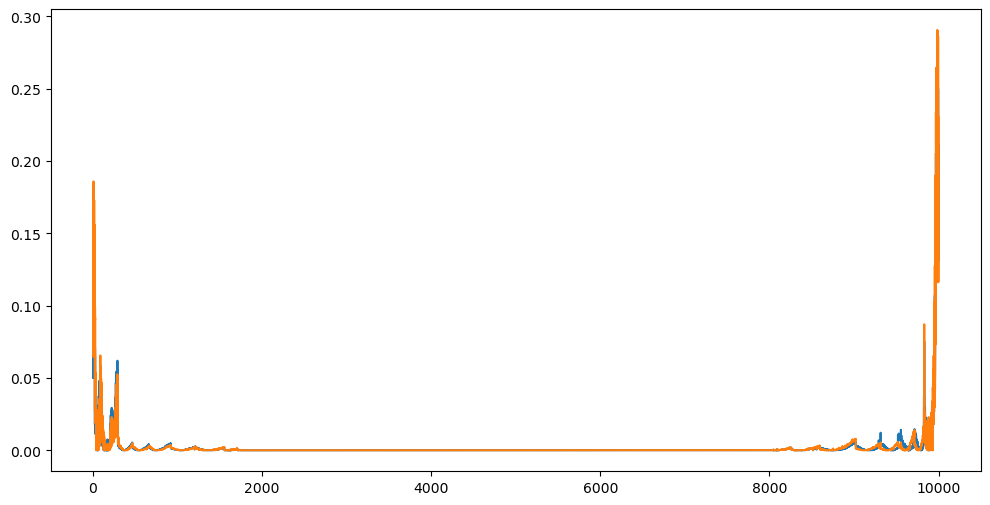

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(np.array(temp).T)
plt.show()

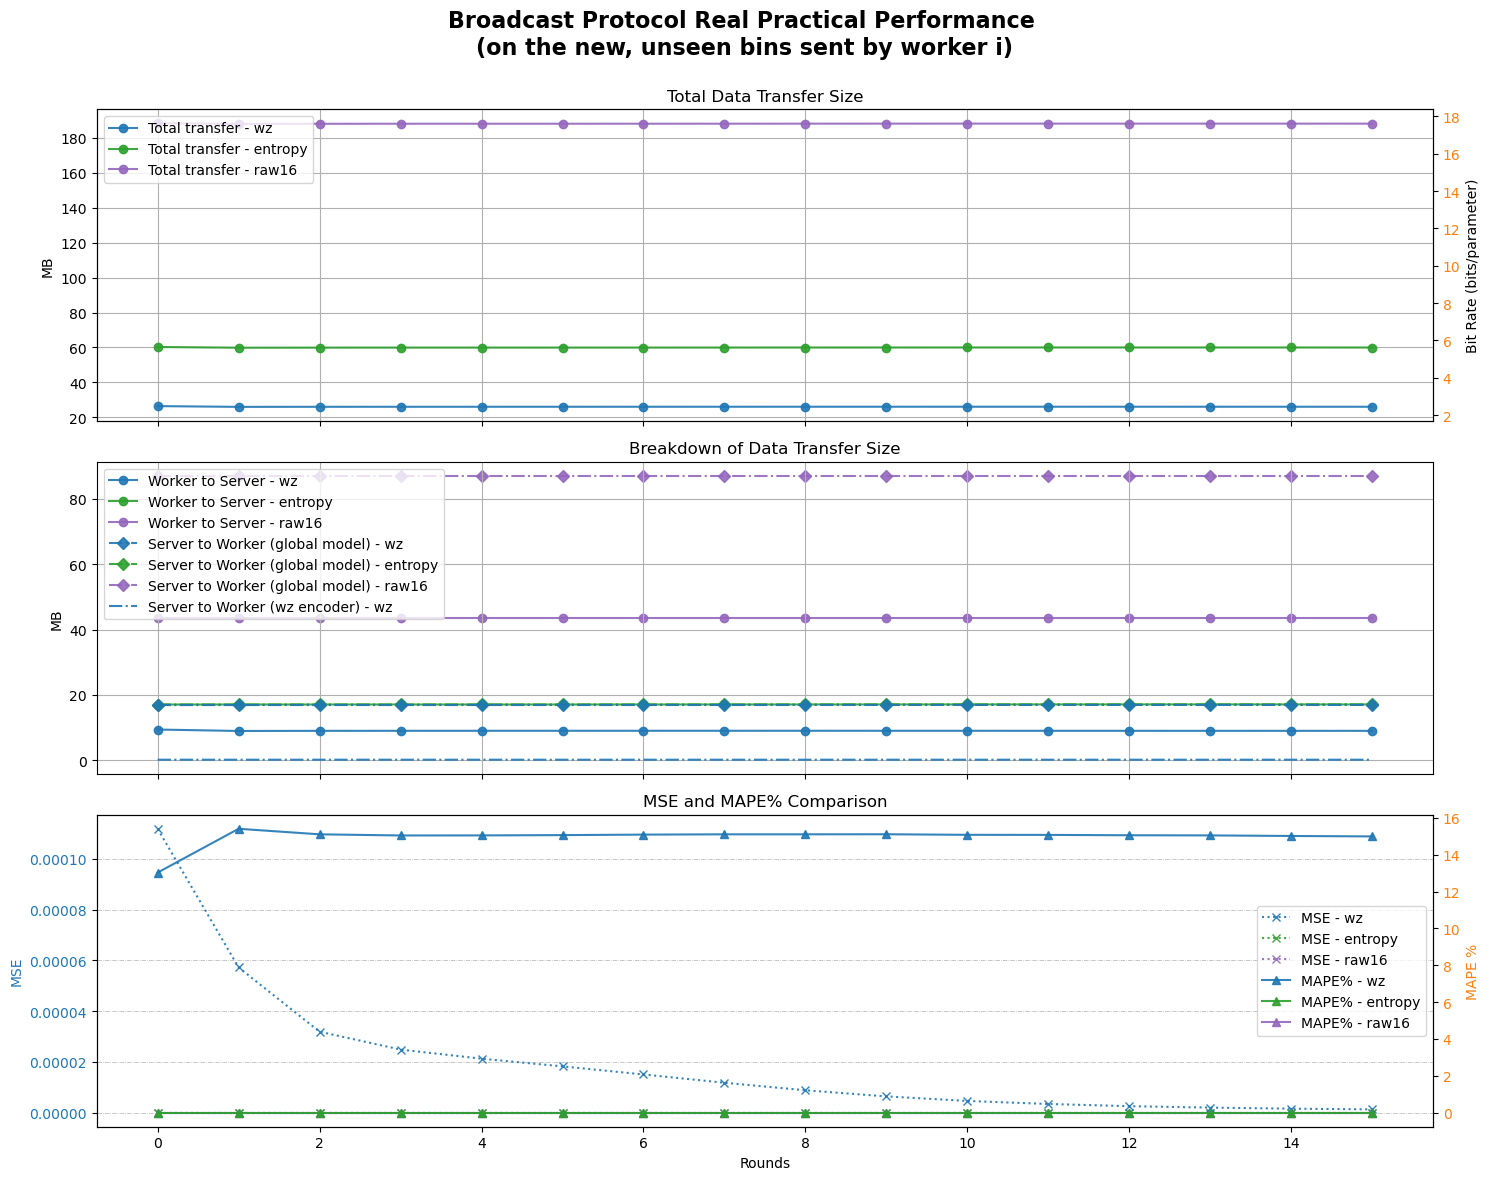

In [17]:
plot_stats(broadcast_prot.entire_stats)